# Embeddings merging strategies analysis

In [1]:
import pandas as pd
import os
import numpy as np
from typing import Literal

In [2]:
base_path = "../"

#### Load data

In [ ]:
df = pd.read_csv("./gridsearch_merging_strategy_final.csv")
# df = pd.read_csv(os.path.join(base_path, "gridsearch_merging_strategy_final.csv"), nrows=4092)
df.head()

,DNABERTBACTSTRAT,NT2PHAGESTRAT,NT2BACTSTRAT,MEGADNAPHAGESTRAT,DNABERTPHAGESTRAT,MEGADNABACTSTRAT,F1Score1,Average
0,BottomTruncateStrategy,BottomTruncateStrategy,BottomTruncateStrategy,MaxStrategy,BottomTruncateStrategy,MaxStrategy,0.911192,0.9111
1,BottomTruncateStrategy,BottomTruncateStrategy,BottomTruncateStrategy,BottomTruncateStrategy,BottomTruncateStrategy,BottomTruncateStrategy,0.908193,0.9081
2,BottomTruncateStrategy,BottomTruncateStrategy,BottomTruncateStrategy,MaxStrategy,BottomTruncateStrategy,BottomTruncateStrategy,0.905137,0.9051
3,BottomTruncateStrategy,BottomTruncateStrategy,BottomTruncateStrategy,BottomTruncateStrategy,BottomTruncateStrategy,MaxStrategy,0.909962,0.9099
4,BottomTruncateStrategy,BottomTruncateStrategy,BottomTruncateStrategy,BottomTruncateStrategy,MaxStrategy,MaxStrategy,0.916012,0.9160


## Analysis

In [117]:
# Get top 10% and bottom 10% thresholds
th_high = np.percentile(df['Average'], 100 - 10/3.5)
th_low = np.percentile(df['Average'], 10/3.5)
# th_high = 0.95
# th_low = 0.80

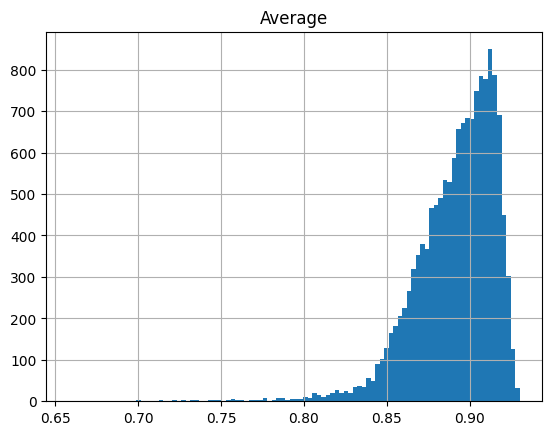

In [118]:
df.hist(column="Average", bins=100);

In [119]:
df.sort_values(axis=0, by="Average", ascending=False, inplace=True, ignore_index=True)
df.head()

,DNABERTBACTSTRAT,NT2PHAGESTRAT,NT2BACTSTRAT,MEGADNAPHAGESTRAT,DNABERTPHAGESTRAT,MEGADNABACTSTRAT,F1Score1,Average
0,TopBottomTruncateStrategy,TKPertStrategy,TopBottomTruncateStrategy,MaxStrategy,TKPertStrategy,BottomTruncateStrategy,0.930166,0.9301
1,TopBottomTruncateStrategy,TKPertStrategy,TopBottomTruncateStrategy,TKPertStrategy,TopBottomTruncateStrategy,MaxStrategy,0.929756,0.9297
2,TopBottomTruncateStrategy,TKPertStrategy,TopBottomTruncateStrategy,MaxStrategy,TruncateStrategy,BottomTruncateStrategy,0.929416,0.9294
3,TopBottomTruncateStrategy,TopBottomTruncateStrategy,TopBottomTruncateStrategy,TKPertStrategy,TopBottomTruncateStrategy,MaxStrategy,0.929329,0.9293
4,BottomTruncateStrategy,TopBottomTruncateStrategy,TopBottomTruncateStrategy,MaxStrategy,MaxStrategy,TruncateStrategy,0.929176,0.9291


In [120]:
df_best = df[df["Average"] >= th_high]
print(f"Number of elements selected as bests: {len(df_best)}")

df_worse = df[df["Average"] < th_low]
print(f"Number of elements selected as worse: {len(df_worse)}")

Number of elements selected as bests: 421
Number of elements selected as worse: 418


In [121]:
DF_COLUMNS = ["NT2PHAGESTRAT", "MEGADNAPHAGESTRAT", "DNABERTPHAGESTRAT", "NT2BACTSTRAT", "MEGADNABACTSTRAT", "DNABERTBACTSTRAT"]
strategies = np.unique(df[DF_COLUMNS].values)

def make_pretty(styler, title: str, cmap: str = "RdYlGn", vmin = None, vmax = None, percentage: bool = False, axis: Literal[0] | None = 0):
    styler.set_caption(title)
    if percentage:
        styler.format(lambda x: f"{x*100:.2f}%" if np.isfinite(x) else x) # type: ignore
    else:
        styler.format(precision=3)
    styler.background_gradient(axis=axis, cmap=cmap, vmin=vmin, vmax=vmax)
    return styler


### Single column analysis

How many of each of them are in the top and bottom

In [122]:
table_best = pd.DataFrame(columns=DF_COLUMNS, index=strategies, dtype=float).fillna(0)
table_worse = pd.DataFrame(columns=DF_COLUMNS, index=strategies, dtype=float).fillna(0)

for column in DF_COLUMNS:
    table_best[column] = df_best[column].value_counts(normalize=True)
    table_worse[column] = df_worse[column].value_counts(normalize=True)

table_best.fillna(0, inplace=True)
table_worse.fillna(0, inplace=True)

In [123]:
table_best.style.pipe(make_pretty, title=f"Best strategies (f1 >= {th_high}: {len(df_best)} exps)", percentage=True)

,NT2PHAGESTRAT,MEGADNAPHAGESTRAT,DNABERTPHAGESTRAT,NT2BACTSTRAT,MEGADNABACTSTRAT,DNABERTBACTSTRAT
BottomTruncateStrategy,3.80%,13.06%,10.45%,3.80%,31.83%,41.33%
MaxStrategy,2.61%,26.13%,19.00%,0.00%,21.85%,6.65%
TKPertStrategy,41.33%,23.52%,23.52%,0.00%,1.19%,0.00%
TopBottomTruncateStrategy,43.71%,15.91%,25.42%,95.72%,24.23%,42.76%
TruncateStrategy,8.55%,21.38%,21.62%,0.48%,20.90%,9.26%


In [124]:
table_worse.style.pipe(make_pretty, title=f"Worse strategies (f1 < {th_low}: {len(df_worse)} exps)", cmap="RdYlGn_r", percentage=True)

,NT2PHAGESTRAT,MEGADNAPHAGESTRAT,DNABERTPHAGESTRAT,NT2BACTSTRAT,MEGADNABACTSTRAT,DNABERTBACTSTRAT
BottomTruncateStrategy,5.26%,29.90%,48.33%,0.00%,7.89%,15.55%
MaxStrategy,38.76%,11.72%,14.35%,80.86%,19.86%,42.34%
TKPertStrategy,3.11%,7.66%,0.00%,17.94%,16.03%,3.35%
TopBottomTruncateStrategy,0.24%,33.49%,22.73%,0.00%,13.64%,18.42%
TruncateStrategy,52.63%,17.22%,14.59%,1.20%,42.58%,20.33%


### Single column analysis

How many experiments for each category are in the top/bottom section

In [97]:
table_best_2 = pd.DataFrame(columns=DF_COLUMNS, index=strategies, dtype=float).fillna(0)
table_worse_2 = pd.DataFrame(columns=DF_COLUMNS, index=strategies, dtype=float).fillna(0)

for column in DF_COLUMNS:
    for strat in strategies:
        table_best_2.loc[strat, column] = len(df_best[df_best[column] == strat]) / len(df[df[column] == strat])
        table_worse_2.loc[strat, column] = len(df_worse[df_worse[column] == strat]) / len(df[df[column] == strat])

table_best_2.fillna(0, inplace=True)
table_worse_2.fillna(0, inplace=True)

In [98]:
table_best_2.style.pipe(make_pretty, title=f"Best strategies (f1 >= {th_high}: {len(df_best)} exps)", percentage=True, axis=None)

,NT2PHAGESTRAT,MEGADNAPHAGESTRAT,DNABERTPHAGESTRAT,NT2BACTSTRAT,MEGADNABACTSTRAT,DNABERTBACTSTRAT
BottomTruncateStrategy,0.56%,2.13%,1.74%,0.73%,5.05%,5.98%
MaxStrategy,0.45%,4.08%,2.93%,0.00%,3.56%,1.12%
TKPertStrategy,6.48%,3.69%,3.73%,0.00%,0.17%,0.00%
TopBottomTruncateStrategy,7.11%,2.61%,4.01%,15.16%,3.83%,6.24%
TruncateStrategy,1.28%,3.20%,3.30%,0.10%,3.10%,2.00%


In [99]:
table_worse_2.style.pipe(make_pretty, title=f"Worse strategies (f1 < {th_low}: {len(df_worse)} exps)", cmap="RdYlGn_r", percentage=True, axis=None)

,NT2PHAGESTRAT,MEGADNAPHAGESTRAT,DNABERTPHAGESTRAT,NT2BACTSTRAT,MEGADNABACTSTRAT,DNABERTBACTSTRAT
BottomTruncateStrategy,0.98%,4.60%,7.35%,0.00%,1.22%,2.21%
MaxStrategy,5.96%,1.78%,2.23%,12.20%,3.07%,6.05%
TKPertStrategy,0.52%,1.19%,0.03%,3.14%,2.68%,0.64%
TopBottomTruncateStrategy,0.07%,5.30%,3.66%,0.00%,2.06%,2.53%
TruncateStrategy,7.33%,2.43%,2.05%,0.16%,5.95%,4.19%


### Single column analysis: Average score for each strategy

In [100]:
weights_table = pd.DataFrame(columns=DF_COLUMNS, index=strategies, dtype=float).fillna(0)

for column in DF_COLUMNS:
    for strat in strategies:
        weights_table.loc[strat, column] = df[df[column] == strat]["Average"].mean()

weights_table.style.pipe(make_pretty, title="Average score", cmap="RdYlGn", vmin=0.86, vmax=0.95)

,NT2PHAGESTRAT,MEGADNAPHAGESTRAT,DNABERTPHAGESTRAT,NT2BACTSTRAT,MEGADNABACTSTRAT,DNABERTBACTSTRAT
BottomTruncateStrategy,0.893,0.888,0.883,0.905,0.897,0.896
MaxStrategy,0.886,0.895,0.892,0.871,0.892,0.887
TKPertStrategy,0.895,0.894,0.899,0.869,0.885,0.886
TopBottomTruncateStrategy,0.897,0.887,0.890,0.914,0.896,0.897
TruncateStrategy,0.885,0.892,0.892,0.896,0.886,0.890


In [101]:
weights_table = pd.DataFrame(columns=DF_COLUMNS, index=strategies, dtype=float).fillna(0)
df_top_bottom = df[(df["Average"] >= th_high) | (df["Average"] < th_low)]

for column in DF_COLUMNS:
    for strat in strategies:
        weights_table.loc[strat, column] = df_top_bottom[df_top_bottom[column] == strat]["Average"].mean()

weights_table.style.pipe(make_pretty, title="Average score (only top + bottom)", cmap="RdYlGn", vmin=0.86, vmax=0.95)

,NT2PHAGESTRAT,MEGADNAPHAGESTRAT,DNABERTPHAGESTRAT,NT2BACTSTRAT,MEGADNABACTSTRAT,DNABERTBACTSTRAT
BottomTruncateStrategy,0.862,0.842,0.829,0.923,0.905,0.893
MaxStrategy,0.823,0.890,0.876,0.807,0.870,0.826
TKPertStrategy,0.918,0.899,0.923,0.829,0.832,0.834
TopBottomTruncateStrategy,0.923,0.852,0.874,0.924,0.888,0.893
TruncateStrategy,0.823,0.875,0.883,0.860,0.844,0.849


## First round removal

In [125]:
remaining_strats = {
    "NT2PHAGESTRAT": ["TruncateStrategy", "BottomTruncateStrategy", "TopBottomTruncateStrategy", "MaxStrategy", "TKPertStrategy"],
    "MEGADNAPHAGESTRAT": ["TruncateStrategy", "BottomTruncateStrategy", "TopBottomTruncateStrategy", "MaxStrategy", "TKPertStrategy"],
    "DNABERTPHAGESTRAT": ["TruncateStrategy", "BottomTruncateStrategy", "TopBottomTruncateStrategy", "MaxStrategy", "TKPertStrategy"],
    "NT2BACTSTRAT": ["TopBottomTruncateStrategy"],
    "MEGADNABACTSTRAT": ["TruncateStrategy", "BottomTruncateStrategy", "TopBottomTruncateStrategy", "MaxStrategy", "TKPertStrategy"],
    "DNABERTBACTSTRAT": ["TruncateStrategy", "BottomTruncateStrategy", "TopBottomTruncateStrategy", "MaxStrategy", "TKPertStrategy"],
}

In [126]:
ndf = df.copy()

for column, strats in remaining_strats.items():
    ndf.drop(ndf[ndf[column].map(lambda x: x not in strats)].index, inplace=True)

print(f"Total elements: {len(ndf)}")
ndf.head()

Total elements: 2869


,DNABERTBACTSTRAT,NT2PHAGESTRAT,NT2BACTSTRAT,MEGADNAPHAGESTRAT,DNABERTPHAGESTRAT,MEGADNABACTSTRAT,F1Score1,Average
0,TopBottomTruncateStrategy,TKPertStrategy,TopBottomTruncateStrategy,MaxStrategy,TKPertStrategy,BottomTruncateStrategy,0.930166,0.9301
1,TopBottomTruncateStrategy,TKPertStrategy,TopBottomTruncateStrategy,TKPertStrategy,TopBottomTruncateStrategy,MaxStrategy,0.929756,0.9297
2,TopBottomTruncateStrategy,TKPertStrategy,TopBottomTruncateStrategy,MaxStrategy,TruncateStrategy,BottomTruncateStrategy,0.929416,0.9294
3,TopBottomTruncateStrategy,TopBottomTruncateStrategy,TopBottomTruncateStrategy,TKPertStrategy,TopBottomTruncateStrategy,MaxStrategy,0.929329,0.9293
4,BottomTruncateStrategy,TopBottomTruncateStrategy,TopBottomTruncateStrategy,MaxStrategy,MaxStrategy,TruncateStrategy,0.929176,0.9291


Number of elements selected as bests: 85
Number of elements selected as worse: 81


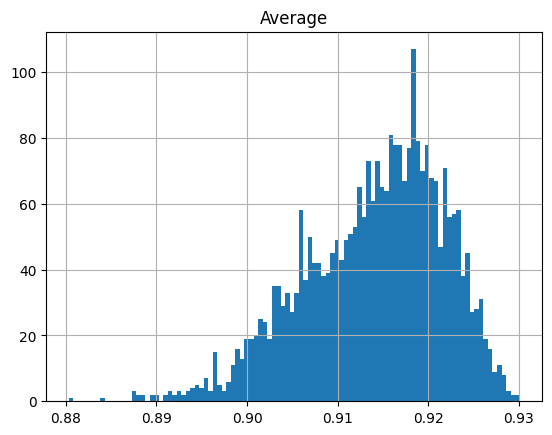

In [127]:
# nth_high = 0.948
# nth_low = 0.91
nth_high = np.percentile(ndf['Average'], 100 - 10/3.5)
nth_low = np.percentile(ndf['Average'], 10/3.5)

ndf_best = ndf[ndf["Average"] >= nth_high]
print(f"Number of elements selected as bests: {len(ndf_best)}")

ndf_worse = ndf[ndf["Average"] < nth_low]
print(f"Number of elements selected as worse: {len(ndf_worse)}")

ndf.hist(column="Average", bins=100);

### Single column analysis

How many of each of them are in the top and bottom

In [128]:
ntable_best = pd.DataFrame(columns=DF_COLUMNS, index=strategies, dtype=float).fillna(0)
ntable_worse = pd.DataFrame(columns=DF_COLUMNS, index=strategies, dtype=float).fillna(0)

for column in DF_COLUMNS:
    ntable_best[column] = ndf_best[column].value_counts(normalize=True)
    ntable_worse[column] = ndf_worse[column].value_counts(normalize=True)

In [129]:
ntable_best.style.pipe(make_pretty, title=f"Best strategies (f1 >= {nth_high}: {len(ndf_best)} exps)", percentage=True)

,NT2PHAGESTRAT,MEGADNAPHAGESTRAT,DNABERTPHAGESTRAT,NT2BACTSTRAT,MEGADNABACTSTRAT,DNABERTBACTSTRAT
BottomTruncateStrategy,1.18%,15.29%,8.24%,nan,54.12%,42.35%
MaxStrategy,nan,22.35%,21.18%,nan,14.12%,nan
TKPertStrategy,60.00%,27.06%,23.53%,nan,nan,nan
TopBottomTruncateStrategy,38.82%,15.29%,28.24%,100.00%,21.18%,55.29%
TruncateStrategy,nan,20.00%,18.82%,nan,10.59%,2.35%


In [130]:
ntable_worse.style.pipe(make_pretty, title=f"Worse strategies (f1 < {nth_low}: {len(ndf_worse)} exps)", cmap="RdYlGn_r", percentage=True)

,NT2PHAGESTRAT,MEGADNAPHAGESTRAT,DNABERTPHAGESTRAT,NT2BACTSTRAT,MEGADNABACTSTRAT,DNABERTBACTSTRAT
BottomTruncateStrategy,17.28%,27.16%,45.68%,nan,nan,1.23%
MaxStrategy,50.62%,7.41%,23.46%,nan,2.47%,14.81%
TKPertStrategy,1.23%,8.64%,nan,nan,71.60%,69.14%
TopBottomTruncateStrategy,nan,35.80%,12.35%,100.00%,4.94%,11.11%
TruncateStrategy,30.86%,20.99%,18.52%,nan,20.99%,3.70%


### Single column analysis

How many experiments for each category are in the top/bottom section

In [24]:
ntable_best_2 = pd.DataFrame(columns=DF_COLUMNS, index=strategies, dtype=float).fillna(0)
ntable_worse_2 = pd.DataFrame(columns=DF_COLUMNS, index=strategies, dtype=float).fillna(0)

for column in DF_COLUMNS:
    for strat in strategies:
        ntable_best_2.loc[strat, column] = len(ndf_best[ndf_best[column] == strat]) / len(ndf[ndf[column] == strat]) if len(ndf[ndf[column] == strat]) != 0 else np.nan
        ntable_worse_2.loc[strat, column] = len(ndf_worse[ndf_worse[column] == strat]) / len(ndf[ndf[column] == strat]) if len(ndf[ndf[column] == strat]) != 0 else np.nan

In [25]:
ntable_best_2.style.pipe(make_pretty, title=f"Best strategies (f1 >= {nth_high}: {len(ndf_best)} exps)", percentage=True, axis=None)

,NT2PHAGESTRAT,MEGADNAPHAGESTRAT,DNABERTPHAGESTRAT,NT2BACTSTRAT,MEGADNABACTSTRAT,DNABERTBACTSTRAT
MaxStrategy,11.00%,16.50%,11.00%,8.60%,12.40%,19.20%
TKPertStrategy,18.00%,7.50%,11.00%,nan,nan,nan
Tf4idfStrategy,7.50%,16.50%,13.50%,nan,nan,nan
TfidfStrategy,14.00%,14.00%,13.50%,nan,nan,nan
TruncateStrategy,12.50%,8.50%,14.00%,16.60%,12.80%,6.00%


In [26]:
ntable_worse_2.style.pipe(make_pretty, title=f"Worse strategies (f1 < {nth_low}: {len(ndf_worse)} exps)", cmap="RdYlGn_r", percentage=True, axis=None)

,NT2PHAGESTRAT,MEGADNAPHAGESTRAT,DNABERTPHAGESTRAT,NT2BACTSTRAT,MEGADNABACTSTRAT,DNABERTBACTSTRAT
MaxStrategy,11.50%,9.00%,12.00%,11.00%,13.00%,11.80%
TKPertStrategy,7.00%,12.00%,2.50%,nan,nan,nan
Tf4idfStrategy,12.50%,7.50%,10.50%,nan,nan,nan
TfidfStrategy,12.50%,7.00%,15.50%,nan,nan,nan
TruncateStrategy,8.50%,16.50%,11.50%,9.80%,7.80%,9.00%
